# EDA 04 — Feature Engineering Study

Last step of the EDA stage. Builds 14 candidate synthetic features motivated by the
findings of EDA 01-03, scores them on Information Value, redundancy and a drop-one
ablation, and selects the 12 that define feature configuration C in the Fitting stage.
The two rejected candidates are kept in the table to document why they were dropped.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [2]:
# Paths, seed and column rename map (same convention as EDA 01).
SEED = 42
DATA_PATH = "../data/cs-training.csv"
RENAME = {
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilisation",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "past_due_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines_and_loans",
    "NumberOfTimes90DaysLate": "past_due_90",
    "NumberRealEstateLoansOrLines": "real_estate_loans_or_lines",
    "NumberOfTime60-89DaysPastDueNotWorse": "past_due_60_89",
    "NumberOfDependents": "dependents",
}

In [3]:
# Load, rename, recode sentinels, and impute with simple medians. This notebook is a
# full-dataset exploration, so a global median is acceptable here; the leakage-safe
# age-conditional imputation is fitted on training data only in Fitting 01.
df = pd.read_csv(DATA_PATH, index_col=0).rename(columns=RENAME)
sentinel_flag = df[["past_due_30_59", "past_due_60_89", "past_due_90"]].isin([96, 98]).any(axis=1).astype(int)
missing_income_flag = df["monthly_income"].isna().astype(int)
for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
    legit_max = df.loc[~df[col].isin([96, 98]), col].max()
    df[col] = df[col].replace({96: legit_max + 1, 98: legit_max + 1})
df["monthly_income"] = df["monthly_income"].fillna(df["monthly_income"].median())
df["dependents"] = df["dependents"].fillna(df["dependents"].median())
y = df["target"]
predictors = [c for c in df.columns if c != "target"]
print(f"rows: {len(df):,} - imputed, sentinels recoded, flags captured from raw data")

rows: 150,000 - imputed, sentinels recoded, flags captured from raw data


In [4]:
# Build the 14 candidate synthetic features. Each one encodes a hypothesis from the
# earlier notebooks: the delinquency family aggregates the three past-due counters, the
# zero-flags capture "any episode vs none", the ratio features normalise debt by household
# size and delinquency by credit activity, and the two multivariate features (Mahalanobis
# distance, multi-extremity count) flag jointly unusual borrowers.
util_band = pd.cut(df["revolving_utilisation"], bins=[-np.inf, 0.0, 0.30, 0.60, 1.00, np.inf],
                   labels=[0, 1, 2, 3, 4], include_lowest=True).astype(int)
cand = pd.DataFrame(index=df.index)
cand["weighted_delinq_score"] = (1 * df["past_due_30_59"] + 2 * df["past_due_60_89"]
                                 + 3 * df["past_due_90"])
cand["combined_delinq_flag"] = ((df["past_due_30_59"] > 0).astype(int)
                                + (df["past_due_60_89"] > 0).astype(int)
                                + (df["past_due_90"] > 0).astype(int))
cand["zero_flag_past_due_30_59"] = (df["past_due_30_59"] == 0).astype(int)
cand["zero_flag_past_due_60_89"] = (df["past_due_60_89"] == 0).astype(int)
cand["zero_flag_past_due_90"] = (df["past_due_90"] == 0).astype(int)
cand["util_delinq_interaction"] = util_band * cand["weighted_delinq_score"]
cand["delinquency_rate"] = cand["weighted_delinq_score"] / df["open_credit_lines_and_loans"].clip(lower=1)
cand["debt_burden_per_dependent"] = df["debt_ratio"] / df["dependents"].clip(lower=1)
cand["sentinel_flag"] = sentinel_flag
cand["zero_flag_open_credit_lines"] = (df["open_credit_lines_and_loans"] == 0).astype(int)
cand["missing_income_flag"] = missing_income_flag
cand["debt_ratio_extreme_flag"] = (df["debt_ratio"] >= 1).astype(int)
# NB: this exploration uses full-data mean/cov for the Mahalanobis distance (feature
# SELECTION only); the deployed feature is fitted train-only in Fitting 02, and the
# train-only check below confirms the verdicts hold on the training split alone.
X_raw = df[predictors].to_numpy(dtype=float)
mu = X_raw.mean(axis=0)
cov_inv = np.linalg.pinv(np.cov(X_raw, rowvar=False) + 1e-6 * np.eye(len(predictors)))
centred = X_raw - mu
d2 = np.clip(np.einsum("ij,jk,ik->i", centred, cov_inv, centred), 0, None)
cand["mahalanobis_log"] = np.log1p(d2)
p99 = df[predictors].quantile(0.99)
cand["multi_extremity_index"] = sum((df[c] > p99[c]).astype(int) for c in predictors)
print(f"{cand.shape[1]} candidate features built")

14 candidate features built


In [5]:
# Information Value and Variance Inflation Factor per candidate. IV is the zero-inflation-
# safe version from EDA 03 (if a plain quantile cut collapses into a single bin because
# the feature is mostly zeros, zero gets its own bin and the positive values are
# quantile-binned separately). VIF is the redundancy lens: VIF_j = 1 / (1 - R^2_j) where
# R^2_j regresses candidate j on all the others, so a high VIF flags a feature that is
# linearly reconstructable from the rest (the delinquency twins). The delinquency family
# scores very strongly on IV; the missing-income flag and the debt-ratio extreme flag are
# essentially uninformative - the first is confounded by age (EDA 02), the second proxies
# income-missingness rather than risk.
from sklearn.linear_model import LinearRegression

def information_value(feature, target, n_bins=10):
    data = pd.DataFrame({"x": feature, "y": target}).dropna()
    if data["x"].nunique() <= n_bins:
        data["bin"] = data["x"]
    else:
        data["bin"] = pd.qcut(data["x"], n_bins, duplicates="drop")
        if data["bin"].nunique() < 2:  # quantile cut collapsed: zero-inflated feature
            positive = data["x"] > 0
            n_pos_bins = min(n_bins - 1, int(data.loc[positive, "x"].nunique()))
            data["bin"] = "zero"
            data.loc[positive, "bin"] = pd.qcut(data.loc[positive, "x"], n_pos_bins,
                                                duplicates="drop").astype(str)
    iv = 0.0
    n_pos, n_neg = (data["y"] == 1).sum(), (data["y"] == 0).sum()
    for _, grp in data.groupby("bin", observed=True):
        pos = ((grp["y"] == 1).sum() + 0.5) / n_pos
        neg = ((grp["y"] == 0).sum() + 0.5) / n_neg
        iv += (pos - neg) * np.log(pos / neg)
    return iv

def vif_series(frame):
    X, out = frame.to_numpy(dtype=float), {}
    for j, col in enumerate(frame.columns):
        others = np.delete(X, j, axis=1)
        r2 = LinearRegression().fit(others, X[:, j]).score(others, X[:, j])
        out[col] = np.inf if r2 >= 1 - 1e-12 else 1.0 / (1.0 - r2)
    return pd.Series(out)

scorecard = pd.DataFrame({
    "spearman": [spearmanr(cand[c], y).statistic for c in cand.columns],
    "IV": [information_value(cand[c], y) for c in cand.columns],
    "VIF": vif_series(cand),
}, index=cand.columns).sort_values("IV", ascending=False)
scorecard.round(4)

,spearman,IV,VIF
combined_delinq_flag,0.3357,1.4014,inf
delinquency_rate,0.3428,1.3657,58.2188
weighted_delinq_score,0.3452,1.2844,65.6246
util_delinq_interaction,0.3467,1.2582,42.1470
mahalanobis_log,0.2230,0.9199,2.1531
zero_flag_past_due_90,-0.3396,0.8376,inf
zero_flag_past_due_30_59,-0.2463,0.6652,inf
zero_flag_past_due_60_89,-0.2752,0.5725,inf
multi_extremity_index,0.1365,0.2106,1.7688
zero_flag_open_credit_lines,0.0857,0.0617,1.2740


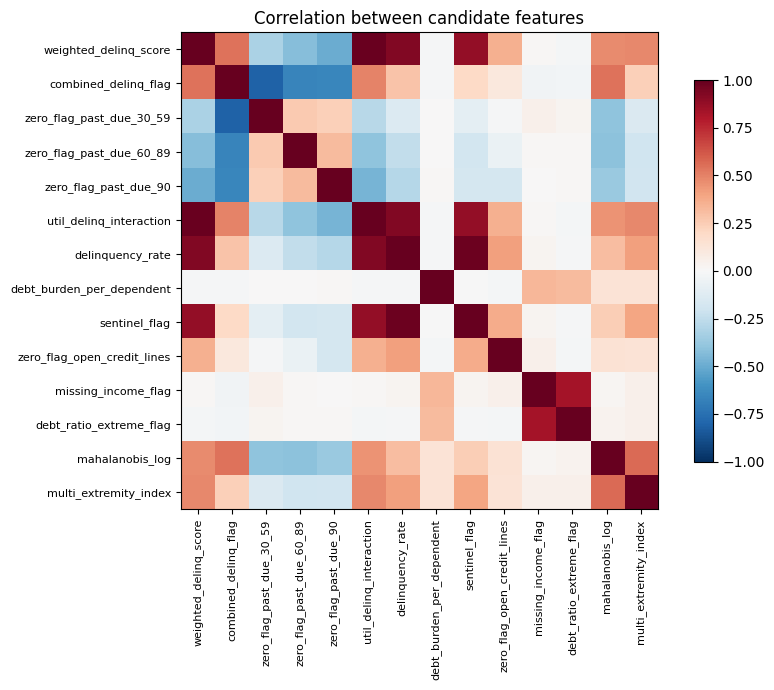

In [6]:
# Redundancy check: correlation between candidates. The delinquency-family features are
# highly inter-correlated by construction; they are kept anyway because the regularised
# Logistic Regression and the tree models can handle redundancy, and each variant offers
# a different functional form to the trees.
fig, ax = plt.subplots(figsize=(9, 7))
corr = cand.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlation between candidate features")
plt.tight_layout()
plt.show()

In [7]:
# Drop-one ablation AND permutation importance, two conditional-contribution lenses on the
# same train/holdout split. Ablation: train a Logistic Regression on the ten raw
# predictors plus all candidates, then re-train dropping one candidate at a time - the AUC
# loss estimates each feature's contribution on top of everything else. Permutation
# importance: fit once, then shuffle each holdout column and measure the AUC drop - cheaper
# and computed on unseen rows. (Both understate collinear twins, which is why the redundant
# delinquency family is judged on IV strength rather than on these conditional lenses.)
from sklearn.inspection import permutation_importance

X_full = pd.concat([df[predictors], cand], axis=1)
X_tr, X_ho, y_tr, y_ho = train_test_split(X_full, y, test_size=0.3,
                                          stratify=y, random_state=SEED)
def holdout_auc(columns):
    model = Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                 random_state=SEED))])
    model.fit(X_tr[columns], y_tr)
    return roc_auc_score(y_ho, model.predict_proba(X_ho[columns])[:, 1])

base_auc = holdout_auc(list(X_full.columns))
base_model = Pipeline([("scaler", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                  random_state=SEED))]).fit(X_tr, y_tr)
perm = permutation_importance(base_model, X_ho, y_ho, scoring="roc_auc",
                              n_repeats=10, random_state=SEED, n_jobs=1)
perm_importance = pd.Series(perm.importances_mean, index=X_full.columns)

ablation = pd.DataFrame({
    "auc_drop_when_removed": [
        base_auc - holdout_auc([c for c in X_full.columns if c != f])
        for f in cand.columns],
    "perm_importance": perm_importance.reindex(cand.columns),
}, index=cand.columns).sort_values("auc_drop_when_removed", ascending=False)
print(f"holdout AUC with all features: {base_auc:.4f}")
ablation.round(5)

holdout AUC with all features: 0.8322


,auc_drop_when_removed,perm_importance
zero_flag_open_credit_lines,0.00266,0.00394
multi_extremity_index,0.00088,0.00112
util_delinq_interaction,0.00070,0.02473
debt_ratio_extreme_flag,0.00054,0.00518
missing_income_flag,0.00048,0.00549
sentinel_flag,0.00037,0.00165
debt_burden_per_dependent,0.00010,0.00517
delinquency_rate,0.00004,0.00102
zero_flag_past_due_60_89,0.00001,0.00568
combined_delinq_flag,-0.00001,0.01243


In [8]:
# Final decision, now over four lenses: IV (univariate strength), VIF (redundancy), the
# drop-one ablation and permutation importance (conditional contribution). Nine candidates
# are kept on clear strength, three are kept as borderline but economically meaningful, and
# two are dropped because they are uninformative on every lens: the missing-income flag and
# the debt-ratio extreme flag. The 12 kept features define feature configuration C in
# Fitting 02.
DROP = ["missing_income_flag", "debt_ratio_extreme_flag"]
decision = scorecard.copy()                       # spearman, IV, VIF
decision["ablation_auc_drop"] = ablation["auc_drop_when_removed"].reindex(decision.index)
decision["perm_importance"] = perm_importance.reindex(decision.index)
decision["verdict"] = ["drop" if f in DROP else "keep" for f in decision.index]

# Sanity: the two dropped flags should also sit among the weakest on the new lenses. This
# is reported, not asserted - the verdict rests on IV ~ 0, the new lenses corroborate it.
for lens in ("IV", "perm_importance"):
    order = decision[lens].rank(ascending=True)         # 1 = weakest
    ranks = {f: int(order[f]) for f in DROP}
    print(f"{lens}: dropped-flag ranks (1 = weakest of {len(decision)}): {ranks}")
print(f"kept: {int((decision.verdict == 'keep').sum())}   dropped: {len(DROP)} {DROP}")
decision.round(4)

IV: dropped-flag ranks (1 = weakest of 14): {'missing_income_flag': 2, 'debt_ratio_extreme_flag': 1}
perm_importance: dropped-flag ranks (1 = weakest of 14): {'missing_income_flag': 8, 'debt_ratio_extreme_flag': 7}
kept: 12   dropped: 2 ['missing_income_flag', 'debt_ratio_extreme_flag']


,spearman,IV,VIF,ablation_auc_drop,perm_importance,verdict
combined_delinq_flag,0.3357,1.4014,inf,-0.0000,0.0124,keep
delinquency_rate,0.3428,1.3657,58.2188,0.0000,0.0010,keep
weighted_delinq_score,0.3452,1.2844,65.6246,-0.0000,0.0016,keep
util_delinq_interaction,0.3467,1.2582,42.1470,0.0007,0.0247,keep
mahalanobis_log,0.2230,0.9199,2.1531,-0.0007,0.0164,keep
zero_flag_past_due_90,-0.3396,0.8376,inf,-0.0000,0.0122,keep
zero_flag_past_due_30_59,-0.2463,0.6652,inf,-0.0000,0.0065,keep
zero_flag_past_due_60_89,-0.2752,0.5725,inf,0.0000,0.0057,keep
multi_extremity_index,0.1365,0.2106,1.7688,0.0009,0.0011,keep
zero_flag_open_credit_lines,0.0857,0.0617,1.2740,0.0027,0.0039,keep


In [9]:
# Sensitivity check: does the selection survive when it only sees training data? The
# scorecard above is full-dataset exploration, so it technically includes rows that later
# become the validation and test splits. This cell reproduces the exact training split of
# Fitting 01 (duplicates dropped first, then a stratified 60/40 cut with the project
# seed), rebuilds every candidate inside that split with train-fitted ingredients
# (imputation medians, Mahalanobis moments, 99th percentiles), and verifies that the
# keep/drop verdicts are unchanged at the conventional IV < 0.02 "useless" cutoff.
raw = pd.read_csv(DATA_PATH, index_col=0).rename(columns=RENAME)
raw = raw.drop_duplicates(keep="first").reset_index(drop=True)
t, _ = train_test_split(raw, train_size=0.60, stratify=raw["target"], random_state=SEED)
t = t.copy()
sent_t = t[["past_due_30_59", "past_due_60_89", "past_due_90"]].isin([96, 98]).any(axis=1).astype(int)
mif_t = t["monthly_income"].isna().astype(int)
for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
    legit_max = t.loc[~t[col].isin([96, 98]), col].max()
    t[col] = t[col].replace({96: legit_max + 1, 98: legit_max + 1})
t["monthly_income"] = t["monthly_income"].fillna(t["monthly_income"].median())
t["dependents"] = t["dependents"].fillna(t["dependents"].median())
y_t = t["target"]
util_band_t = pd.cut(t["revolving_utilisation"], bins=[-np.inf, 0.0, 0.30, 0.60, 1.00, np.inf],
                     labels=[0, 1, 2, 3, 4], include_lowest=True).astype(int)
ct = pd.DataFrame(index=t.index)
ct["weighted_delinq_score"] = (1 * t["past_due_30_59"] + 2 * t["past_due_60_89"]
                               + 3 * t["past_due_90"])
ct["combined_delinq_flag"] = ((t["past_due_30_59"] > 0).astype(int)
                              + (t["past_due_60_89"] > 0).astype(int)
                              + (t["past_due_90"] > 0).astype(int))
ct["zero_flag_past_due_30_59"] = (t["past_due_30_59"] == 0).astype(int)
ct["zero_flag_past_due_60_89"] = (t["past_due_60_89"] == 0).astype(int)
ct["zero_flag_past_due_90"] = (t["past_due_90"] == 0).astype(int)
ct["util_delinq_interaction"] = util_band_t * ct["weighted_delinq_score"]
ct["delinquency_rate"] = ct["weighted_delinq_score"] / t["open_credit_lines_and_loans"].clip(lower=1)
ct["debt_burden_per_dependent"] = t["debt_ratio"] / t["dependents"].clip(lower=1)
ct["sentinel_flag"] = sent_t
ct["zero_flag_open_credit_lines"] = (t["open_credit_lines_and_loans"] == 0).astype(int)
ct["missing_income_flag"] = mif_t
ct["debt_ratio_extreme_flag"] = (t["debt_ratio"] >= 1).astype(int)
X_t = t[predictors].to_numpy(dtype=float)
cov_inv_t = np.linalg.pinv(np.cov(X_t, rowvar=False) + 1e-6 * np.eye(len(predictors)))
centred_t = X_t - X_t.mean(axis=0)
d2_t = np.clip(np.einsum("ij,jk,ik->i", centred_t, cov_inv_t, centred_t), 0, None)
ct["mahalanobis_log"] = np.log1p(d2_t)
p99_t = t[predictors].quantile(0.99)
ct["multi_extremity_index"] = sum((t[c] > p99_t[c]).astype(int) for c in predictors)

train_check = pd.DataFrame({
    "IV_full": scorecard["IV"],
    "IV_train_only": [information_value(ct[c], y_t) for c in scorecard.index],
}, index=scorecard.index)
train_check["verdict_full"] = decision.loc[train_check.index, "verdict"]
train_check["verdict_train_only"] = np.where(train_check["IV_train_only"] < 0.02, "drop", "keep")
assert (train_check["verdict_full"] == train_check["verdict_train_only"]).all(), \
    "train-only selection disagrees with full-data selection"
print("train-only check passed: same 12 keep / 2 drop verdicts on the training split alone")
train_check.round(4)

train-only check passed: same 12 keep / 2 drop verdicts on the training split alone


,IV_full,IV_train_only,verdict_full,verdict_train_only
combined_delinq_flag,1.4014,1.3788,keep,keep
delinquency_rate,1.3657,1.3650,keep,keep
weighted_delinq_score,1.2844,1.2842,keep,keep
util_delinq_interaction,1.2582,1.2587,keep,keep
mahalanobis_log,0.9199,0.9094,keep,keep
zero_flag_past_due_90,0.8376,0.8396,keep,keep
zero_flag_past_due_30_59,0.6652,0.6408,keep,keep
zero_flag_past_due_60_89,0.5725,0.5535,keep,keep
multi_extremity_index,0.2106,0.2521,keep,keep
zero_flag_open_credit_lines,0.0617,0.0669,keep,keep
